In [1]:
"""Test upward backscattering of rough surfaces"""
import sys
sys.path.append('../../../')
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.constants as sci_const
import matplotlib.pyplot as plt

from mores.interface.fBmSSA_upward import Mue_upward_fBmSSA

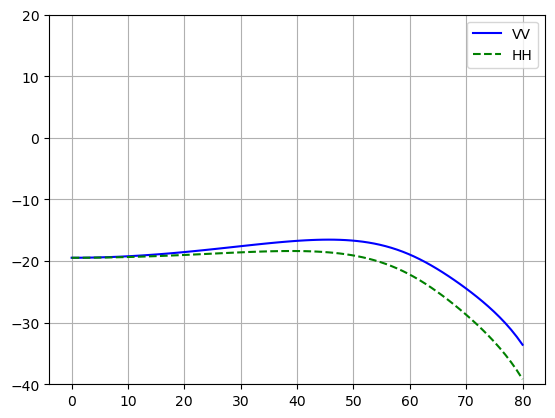

In [3]:
f = 0.44e9
s0 = np.sqrt(307e-3)
H = 0.79
# epsr = 3.0 - 0.1j
# epsr = 1e16
epsr = 1.7
c = sci_const.speed_of_light
Lambda = c / f
k = 2 * np.pi / Lambda

theta_is = np.linspace(0, 80, 80)

N = len(theta_is)
vvs = np.zeros(N)
hhs = np.zeros(N)
for i in range(N):
    theta_i = theta_is[i]
    theta_s = theta_i
    Mue = Mue_upward_fBmSSA(f, (theta_s, 180), (theta_i, 0), epsr, s0, H, shadow_flag=False)
    vvs[i] = 10*np.log10(4*np.pi * Mue[0, 0])
    hhs[i] = 10*np.log10(4*np.pi * Mue[1, 1])


# show
fig, ax = plt.subplots()
ax.plot(theta_is, vvs, 'b-', label='VV')
ax.plot(theta_is, hhs, 'g--', label='HH')
ax.grid()
ax.set_ylim(-40, 20)
plt.legend()
plt.show()